# This is a simple example for a crashPBO on a synthetic function

Here, we draw a sample from a two-dimensional GP. The feasible region is approximately 50% of the domain.  

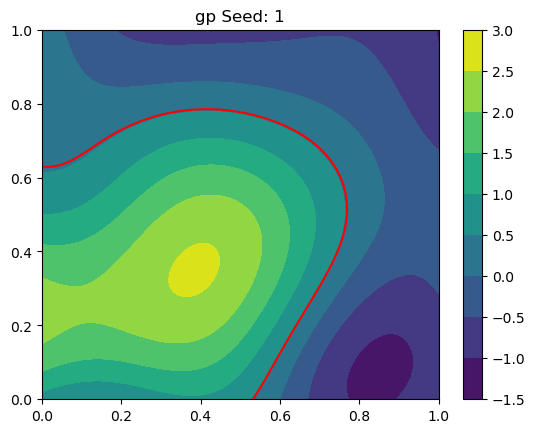

In [73]:
from crashpbo.utils.utility_functions import TestFunction
from crashpbo.interface.crashEUBO import CrashEUBO
from crashpbo.utils.front_end_utils import add_single_comparison
import matplotlib.pyplot as plt
import warnings

# surpress warnings botorch
warnings.filterwarnings("ignore", category=UserWarning, module='botorch')

# Initialize the test function
test_function = TestFunction(name="gp", dim=2, seed=1, feasible_percentage=0.5)

# Plot the test function
fig, ax = test_function.plot_function(path=None, return_axes=True)

## Function to generate comparisons

As we cannot observe the function directly but only via pairwise comparisons, we emulate this with this function. 

In [74]:
import numpy as np
import torch
from itertools import combinations

def generate_comparisons(y, n_comp, replace=False):
        """
        Generate pairwise comparisons with noise.

        Args:
            y (torch.Tensor): Latent utility values.
            n_comp (int): Number of comparisons to generate.
            replace (bool): Whether to sample with replacement.

        Returns:
            torch.Tensor: Pairwise comparison indices.
        """
        # generate all possible pairs of elements in y
        all_pairs = np.array(list(combinations(range(y.shape[0]), 2)))
        # randomly select n_comp pairs from all_pairs
        comp_pairs = all_pairs[
            np.random.choice(range(len(all_pairs)), n_comp, replace=replace)
        ]
        # add gaussian noise to the latent y values
        c0 = y[comp_pairs[:, 0]]
        c1 = y[comp_pairs[:, 1]]
        reverse_comp = (c0 < c1).numpy()
        comp_pairs[reverse_comp, :] = np.flip(comp_pairs[reverse_comp, :], 1)
        comp_pairs = torch.tensor(comp_pairs).long()
        return comp_pairs
    


In [ ]:
# Generate initial random points
init_X, init_y = test_function.generate_random_points(2)
print("Initial Points:", init_X)
print("Initial Utilities:", init_y)

comps = generate_comparisons(init_y, n_comp=1)
print(comps)

crash_eubo = CrashEUBO(
    problem_dim=2, 
    data_folder="./results", 
    compare_to_best=True
)
print(init_y)

# Fit the GP model
mll, model = crash_eubo.init_and_fit_model(init_X, comps)

With this function, we can do the BO loop, which we run for 20 iterations. 
In this setting, we only compare to the best observed point so far, instead of generating two new points every time. This is the setting, which is also used in the hardware experiments. 

In [ ]:
# Initialize variables for the loop
x = init_X
idx_crash = []
idx_not_crash = []
threshold = test_function.threshold
print(threshold)

print(x)
print(comps)

# get best x from comparison
best_x = x[comps[0][0]].unsqueeze(0)  # The first index in the pair is the winner
best_y = test_function(best_x) + torch.randn(best_x.shape[0]) * 0.01  # Adding noise
# CrashPBO loop
for i in range(20):
    print(f"Iteration {i+1}")
    crash_eubo.init_and_fit_model(x, comps)
    # Get the next point(s) using Bayesian Optimization
    next_X = crash_eubo.make_bo_step(x, comps, best_x)
    
    # Simulate decision-making process
    y_next = test_function(next_X)
    y = torch.cat([best_y, y_next])
    if y[0] < threshold and y[1] < threshold:
        decision = "both crashed"
    elif y[0] < threshold:
        decision = "1 crashed"
    elif y[1] < threshold:
        decision = "2 crashed"
    else:
        decision = "1 > 2" if y[0] > y[1] else "2 > 1"
    
    comparison_dict = {
            "Experiment 1": {"Parameters": x[-1].tolist(), "Id": f"exp_{i}_1"},
            "Experiment 2": {"Parameters": next_X[0].tolist(), "Id": f"exp_{i}_2"},
            "Decision": decision,
    }
    print("Comparison Dictionary:", comparison_dict)
    
    # Parse the comparison dictionary into BO data
    x, comps, idx_crash, idx_not_crash = add_single_comparison(idx_crash, idx_not_crash , x, comps, comparison_dict)
    print(idx_crash, idx_not_crash)
    
    # Update the GP model
    _, model = crash_eubo.init_and_fit_model(x, comps)
    last_comparison = comps[-1]
    winner_index = last_comparison[0] # The winner is the first index in the pair
    # ensure best_x is a 2D tensor
    best_x = x[winner_index].unsqueeze(0)
    best_y = test_function(best_x) 
    print(best_x, best_y)
    
    
# Plot the points and connections
plt.figure(figsize=(8, 6))
# mark crash points in red and non-crash points in blue
crash_points = x[idx_crash]
non_crash_points = x[idx_not_crash]



# Plot of the results of crashed and not crashed points
Finally, we can plot the function evaluations. 

In [ ]:
# Plot performance of the best point over iterations

print(x)
y = test_function(x)
plt.plot(y, marker='o', label='Best Point Performance', color='orange')

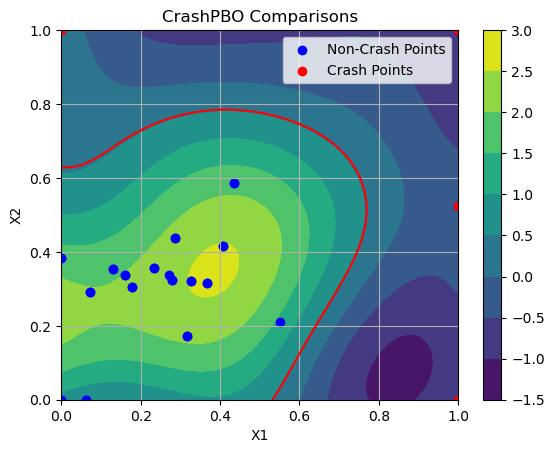

In [78]:
# plot testfunction
test_function.plot_function(path=None, return_axes=False)

plt.scatter(non_crash_points[:, 0], non_crash_points[:, 1], c="blue", label="Non-Crash Points")
plt.scatter(crash_points[:, 0], crash_points[:, 1], c="red", label="Crash Points")
plt.title("CrashPBO Comparisons")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()